In [2]:
import numpy as np
import matplotlib.pyplot as plt
# h5py is used to read and write HDF5 (.h5) files, which store large numerical datasets efficiently
import h5py
# scipy is a scientific computing library offering many advanced mathematical functions
import scipy
# PIL (Pillow) Image module is used to open, manipulate, and save many different image file formats
from PIL import Image
# scipy.ndimage provides functions for image processing and working with n-dimensional arrays (e.g., filters, transformations)
from scipy import ndimage
%matplotlib inline

In [8]:
import requests
import io

# GitHub file URLs (RAW links would be better, but let's use what you sent)
train_url = 'https://github.com/DaJunn/Andrew-NG/raw/DeepLearning.AI/train_catvnoncat.h5'
test_url  = 'https://github.com/DaJunn/Andrew-NG/raw/DeepLearning.AI/test_catvnoncat.h5'

# Download the train file
train_response = requests.get(train_url)
train_bytes = io.BytesIO(train_response.content)

# Download the test file
test_response = requests.get(test_url)
test_bytes = io.BytesIO(test_response.content)

# Open the HDF5 files from memory
train_dataset = h5py.File(train_bytes, 'r')
test_dataset = h5py.File(test_bytes, 'r')

# Extract data
train_set_x_orig = np.array(train_dataset["train_set_x"][:])
train_set_y_orig = np.array(train_dataset["train_set_y"][:])
classes = np.array(train_dataset["list_classes"][:])

test_set_x_orig = np.array(test_dataset["test_set_x"][:])
test_set_y_orig = np.array(test_dataset["test_set_y"][:])

# Reshape labels
train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

print("✅ Loaded data directly from GitHub!")
print(f"Training set shape: {train_set_x_orig.shape}")
print(f"Training labels shape: {train_set_y_orig.shape}")
print(f"Test set shape: {test_set_x_orig.shape}")
print(f"Test labels shape: {test_set_y_orig.shape}")
print(f"Classes: {classes}")

✅ Loaded data directly from GitHub!
Training set shape: (209, 64, 64, 3)
Training labels shape: (1, 209)
Test set shape: (50, 64, 64, 3)
Test labels shape: (1, 50)
Classes: [b'non-cat' b'cat']


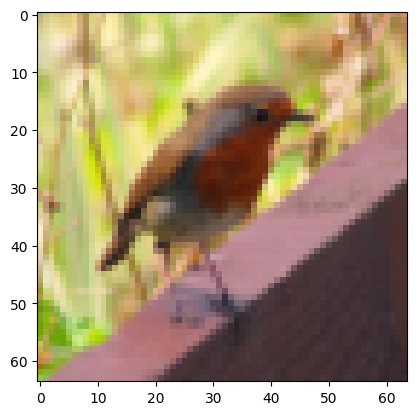

In [9]:
index = 10
plt.imshow(train_set_x_orig[index])

In [11]:
m_train = train_set_x_orig.shape[0]
m_test =  test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]

In [13]:
print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))
print ("Height/Width of each image: num_px = " + str(num_px))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_set_x shape: " + str(train_set_x_orig.shape))
print ("train_set_y shape: " + str(train_set_y_orig.shape))
print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y_orig.shape))

Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Height/Width of each image: num_px = 64
Each image is of size: (64, 64, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


In [17]:
train_set_x_flatten = train_set_x_orig.reshape(
    train_set_x_orig.shape[1] *  train_set_x_orig.shape[2] *  train_set_x_orig.shape[3],train_set_x_orig.shape[0]
)
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[1]*test_set_x_orig.shape[2]*test_set_x_orig.shape[3],test_set_x_orig.shape[0])

print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y_orig.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y_orig.shape))
print ("sanity check after reshaping: " + str(train_set_x_flatten[0:5,0]))

train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)
sanity check after reshaping: [17 71 49 38 70]


In [18]:
train_set_x = train_set_x_flatten/255.
test_set_x = test_set_x_flatten/255.

In [19]:
def sigmoid(z):
    s = 1 / (1 + np.exp(-z))
    return s

In [20]:
def initialize_with_he(dim):
    W = np.random.randn(dim, 1) * np.sqrt(2. / dim)
    b = 0.0
    return W, b

In [21]:
dim = 2
w, b = initialize_with_he(dim)
print ("w = " + str(w))
print ("b = " + str(b))

w = [[-0.68556933]
 [ 2.12191238]]
b = 0.0


In [24]:
def propagate(w, b, X, Y):
    m = X.shape[1]

    # Forward Propagation
    Z = np.dot(w.T, X) + b     
    A = sigmoid(Z)
    cost = - (1/m) * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))  

    # Backward Propagation
    dw = (1/m) * np.dot(X, (A - Y).T)
    db = (1/m) * np.sum(A - Y)

    grads = {"dw": dw,
             "db": db}
    
    return grads, cost

In [25]:
w, b, X, Y = np.array([[1.],[2.]]), 2., np.array([[1.,2.,-1.],[3.,4.,-3.2]]), np.array([[1,0,1]])
grads, cost = propagate(w, b, X, Y)
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))

dw = [[0.99845601]
 [2.39507239]]
db = 0.001455578136784208
cost = 5.801545319394553


In [28]:
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost = False):
    costs = []
    for i in range(num_iterations):
        grads, cost = propagate(w, b, X, Y)
        dw = grads["dw"]
        db = grads["db"]
        w = w - (learning_rate * dw)
        b = b - (learning_rate * db)
        if i % 100 == 0:
            costs.append(cost)
        if print_cost and i % 100 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))
    
    params = {"w": w,
              "b": b}
    
    grads = {"dw": dw,
             "db": db}
    
    return params, grads, costs

In [29]:
params, grads, costs = optimize(w, b, X, Y, num_iterations= 100, learning_rate = 0.009, print_cost = False)

print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))

w = [[0.19033591]
 [0.12259159]]
b = 1.9253598300845747
dw = [[0.67752042]
 [1.41625495]]
db = 0.21919450454067657


In [32]:
def predict(w, b, X):
    m = X.shape[1]
    Y_prediction = np.zeros((1,m))
    w = w.reshape(X.shape[0], 1)
    A = sigmoid(np.dot(w.T,X) + b)
    Y_prediction = (A >= 0.5) * 1.0
    return Y_prediction

In [33]:
w = np.array([[0.1124579],[0.23106775]])
b = -0.3
X = np.array([[1.,-1.1,-3.2],[1.2,2.,0.1]])
print ("predictions = " + str(predict(w, b, X)))

predictions = [[1. 1. 0.]]


In [34]:
def model(X_train, Y_train, X_test, Y_test, num_iterations = 2000, learning_rate = 0.5, print_cost = False):
    w, b = initialize_with_he(X_train.shape[0])
    params, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)
    w = params['w']
    b = params['b']
    Y_prediction_test = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)
    print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))
    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test, 
         "Y_prediction_train" : Y_prediction_train, 
         "w" : w, 
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}
    
    return d

In [36]:
d = model(train_set_x, train_set_y_orig, test_set_x, test_set_y_orig, num_iterations = 2000, learning_rate = 0.005, print_cost = False)

train accuracy: 91.38755980861244 %
test accuracy: 52.0 %


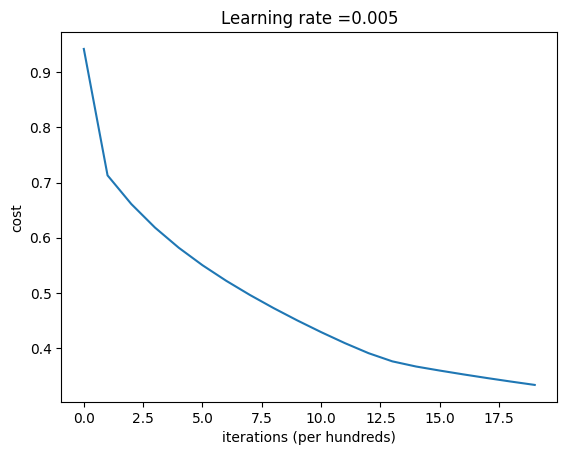

In [39]:
costs = np.squeeze(d['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(d["learning_rate"]))
plt.show()

learning rate is: 0.01
train accuracy: 71.29186602870814 %
test accuracy: 34.0 %

-------------------------------------------------------

learning rate is: 0.001
train accuracy: 72.72727272727273 %
test accuracy: 36.0 %

-------------------------------------------------------

learning rate is: 0.0001
train accuracy: 68.42105263157895 %
test accuracy: 36.0 %

-------------------------------------------------------



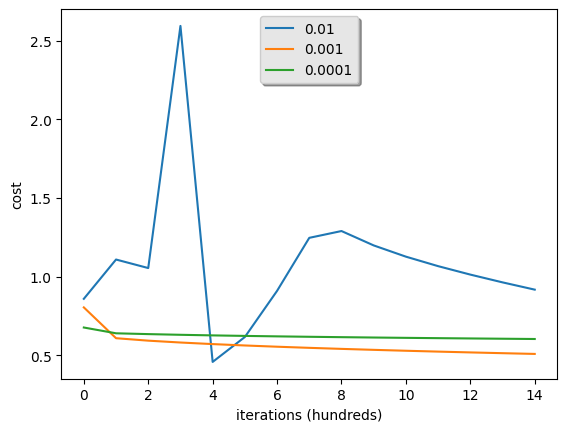

In [42]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}
for i in learning_rates:
    print ("learning rate is: " + str(i))
    models[str(i)] = model(train_set_x, train_set_y_orig, test_set_x, test_set_y_orig, num_iterations = 1500, learning_rate = i, print_cost = False)
    print ('\n' + "-------------------------------------------------------" + '\n')

for i in learning_rates:
    plt.plot(np.squeeze(models[str(i)]["costs"]), label= str(models[str(i)]["learning_rate"]))

plt.ylabel('cost')
plt.xlabel('iterations (hundreds)')

legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()